# JaxSim as a hardware-accelerated parallel physics engine-advanced usage

JaxSim is developed to optimize synthetic data generation by sampling trajectories using hardware accelerators such as GPUs and TPUs.

In this notebook, you'll learn how to use the key APIs to load a simple robot model (a sphere) and simulate multiple trajectories in parallel on GPUs.

<a target="_blank" href="https://colab.research.google.com/github/ami-iit/jaxsim/blob/main/examples/jaxsim_as_physics_engine_advanced.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Prepare the environment

In [1]:
# @title Imports and setup
import sys

# ================
# Notebook imports
# ================

import os

if sys.platform == 'darwin':
    os.environ["MUJOCO_GL"] = "glfw"
else:
    os.environ["MUJOCO_GL"] = "egl"

import jax

import jax.numpy as jnp
import jaxsim.api as js
import rod
from jaxsim import logging
from rod.builder.primitives import SphereBuilder

logging.set_logging_level(logging.LoggingLevel.WARNING)
print(f"Running on {jax.devices()}")

jaxsim[42204] INFO Enabling JAX to use 64-bit precision


Running on [CpuDevice(id=0)]


## Prepare the simulation

JaxSim supports loading robot descriptions from both [SDF][sdformat] and [URDF][urdf] files. This is done using the [`ami-iit/rod`][rod] library, which processes these formats.

The `rod` library also allows creating in-memory models that can be serialized to SDF or URDF. We'll use this functionality to build a sphere model, which will later be used to create the JaxSim model.

[sdformat]: http://sdformat.org/
[urdf]: http://wiki.ros.org/urdf/
[rod]: https://github.com/ami-iit/rod

In [2]:
# @title Create the model description of a sphere

# Create a SDF model.
# The builder takes care to compute the right inertia tensor for you.
rod_sdf = rod.Sdf(
    version="1.7",
    model=SphereBuilder(radius=0.10, mass=1.0, name="sphere")
    .build_model()
    .add_link()
    .add_inertial()
    .add_visual()
    .add_collision()
    .build(),
)

# Rod allows to update the frames w.r.t. the poses are expressed.
rod_sdf.model.switch_frame_convention(
    frame_convention=rod.FrameConvention.Urdf, explicit_frames=True
)

# Serialize the model to a SDF string.
model_sdf_string = rod_sdf.serialize(pretty=True)
print(model_sdf_string)

<?xml version="1.0" encoding="utf-8"?>
<sdf version="1.7">
  <model name="sphere">
    <pose>0.0 0.0 0.0 0.0 0.0 0.0</pose>
    <link name="sphere_link">
      <pose relative_to="__model__">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      <inertial>
        <mass>1.0</mass>
        <inertia>
          <ixx>0.004000000000000001</ixx>
          <iyy>0.004000000000000001</iyy>
          <izz>0.004000000000000001</izz>
          <ixy>0.0</ixy>
          <ixz>0.0</ixz>
          <iyz>0.0</iyz>
        </inertia>
        <pose relative_to="sphere_link">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      </inertial>
      <visual name="sphere_visual">
        <geometry>
          <sphere>
            <radius>0.1</radius>
          </sphere>
        </geometry>
        <pose relative_to="sphere_link">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      </visual>
      <collision name="sphere_collision">
        <geometry>
          <sphere>
            <radius>0.1</radius>
          </sphere>
        </geometry>
        <pose relative_

In [3]:
import jaxsim

# Create the JaxSim model.
# This is shared among all the parallel instances.
model = js.model.JaxSimModel.build_from_model_description(
    model_description=rod_sdf,
    time_step=0.001,
    contact_model=jaxsim.rbda.contacts.SoftContacts(),
)

# Create the data of a single model.
# We will create a vectorized instance later.
data = js.data.JaxSimModelData.build(model=model, base_position=jnp.array([0.0, 0.0, 0.11]))

In [4]:
T = jnp.arange(start=0, stop=3.0, step=model.time_step) # Initialize the simulated time.

In [5]:
import jaxsim
def sphere_plane(
    terrain,
    size,
    center
):
    """
    Detects contacts between a sphere and a plane terrain.

    Args:
        terrain: The terrain object.
        size: The size of the sphere.
        center: The center of the sphere.

    Returns:
        A tuple containing the distance from the sphere to the plane and the pose transform
        of the contact frame.
    """
    normal = terrain.normal(x=center[0], y=center[1])
    distance = jnp.dot(center - terrain._height, normal) - size[0]
    position = normal * (size[0] + 0.5 * distance) - center
    W_H_C = jaxsim.math.Transform.from_rotation_and_translation(
        rotation=jaxsim.math.Rotation.from_axis_angle(normal),
        translation=-position,
    )
    return distance, W_H_C

In [17]:
from jaxsim.rbda.contacts.common import compute_penetration_data
from jaxsim.rbda.contacts import detection
from jaxsim.api.common import ModelDataWithVelocityRepresentation
from jaxsim import VelRepr

K=1e5
D=1e3
mu=1.0

p= 0.5
q= 0.5

def hunt_crossley(model, data):
    """Copy of the Hunt-Crossley contact model from jaxsim.rbda.contacts.soft with different contact detection."""

    m = jnp.array(data.contact_state["tangential_deformation"], dtype=float).squeeze()

    # TODO: The transform of the root link does not match with the actual base position.
    # For this reason, we use the base position instead of the first link transform.
    W_p_C, W_ṗ_C = data.base_position, data._link_velocities[:, :3][0]

    # Use symbol for the static friction.
    μ = mu

    # Compute the distance and the contact frame transform.
    dist, W_H_C = sphere_plane(model.terrain, model.kin_dyn_parameters.contact_parameters.shape_size, W_p_C)

    δ = jnp.maximum(0.0, -dist)  # Ensure non-negative distance

    # In the case of sphere-plane contact, the normal is always the z-axis.
    δ̇ = -W_ṗ_C[2]
    n̂ = W_H_C[:3, 2]

    # There are few operations like computing the norm of a vector with zero length
    # or computing the square root of zero that are problematic in an AD context.
    # To avoid these issues, we introduce a small tolerance ε to their arguments
    # and make sure that we do not check them against zero directly.
    ε = jnp.finfo(float).eps

    # Compute the powers of the penetration depth.
    # Inject ε to address AD issues in differentiating the square root when
    #  p and q are fractional.
    δp = jnp.power(δ + ε, p)
    δq = jnp.power(δ + ε, q)

    # ========================
    # Compute the normal force
    # ========================

    # Non-linear spring-damper model (Hunt/Crossley model).
    # This is the force magnitude along the direction normal to the terrain.
    force_normal_mag = (K * δp) * δ + (D * δq) * δ̇

    # Depending on the magnitude of δ̇, the normal force could be negative.
    force_normal_mag = jnp.maximum(0.0, force_normal_mag)

    # Compute the 3D linear force in C[W] frame.
    f_normal = force_normal_mag * n̂

    # ============================
    # Compute the tangential force
    # ============================

    # Extract the tangential component of the velocity.
    v_tangential = W_ṗ_C - jnp.dot(W_ṗ_C, n̂) * n̂

    # Extract the normal and tangential components of the material deformation.
    m_normal = jnp.dot(m, n̂) * n̂
    m_tangential = m - jnp.dot(m, n̂) * n̂

    # Compute the tangential force in the sticking case.
    # Using the tangential component of the material deformation should not be
    # necessary if the sticking-slipping transition occurs in a terrain area
    # with a locally constant normal. However, this assumption is not true in
    # general, especially for highly uneven terrains.
    f_tangential = -((K * δp) * m_tangential + (D * δq) * v_tangential)

    # Detect the contact type (sticking or slipping).
    # Note that if there is no contact, sticking is set to True, and this detail
    # is exploited in the computation of the `contact_status` variable.
    sticking = jnp.logical_or(
        δ <= 0, f_tangential.dot(f_tangential) <= (μ * force_normal_mag) ** 2
    )

    # Compute the direction of the tangential force.
    # To prevent dividing by zero, we use a switch statement.
    norm = jaxsim.math.safe_norm(f_tangential)
    f_tangential_direction = f_tangential / (
        norm + jnp.finfo(float).eps * (norm == 0)
    )

    # Project the tangential force to the friction cone if slipping.
    f_tangential = jnp.where(
        sticking,
        f_tangential,
        jnp.minimum(μ * force_normal_mag, norm) * f_tangential_direction,
    )

    # Set the tangential force to zero if there is no contact.
    f_tangential = jnp.where(δ <= 0, jnp.zeros(3), f_tangential)

    # =====================================
    # Compute the material deformation rate
    # =====================================

    # Compute the derivative of the material deformation.
    # Note that we included an additional relaxation of `m_normal` in the
    # sticking case, so that the normal deformation that could have accumulated
    # from a previous slipping phase can relax to zero.
    ṁ_no_contact = -(K / D) * m
    ṁ_sticking = v_tangential - (K / D) * m_normal
    ṁ_slipping = -(f_tangential + (K * δp) * m_tangential) / (D * δq)

    # Compute the contact status:
    # 0: slipping
    # 1: sticking
    # 2: no contact
    contact_status = sticking.astype(int)
    contact_status += (δ <= 0).astype(int)

    # Select the right material deformation rate depending on the contact status.
    ṁ = jax.lax.select_n(contact_status, ṁ_slipping, ṁ_sticking, ṁ_no_contact)

    # ==========================================
    # Compute and return the final contact force
    # ==========================================

    # Sum the normal and tangential forces.
    CW_fl = f_normal + f_tangential

    return jnp.hstack([CW_fl, jnp.zeros(3)]), {"tangential_deformation": ṁ}

def generate_contact_force(model, data):

    # TODO: This is for a single collision pair.
    return hunt_crossley(model, data)


In [18]:
# @title Generate batched initial data

# Create a random JAX key.
key = jax.random.PRNGKey(seed=0)

# Split subkeys for sampling random initial data.
batch_size = 9
row_length = int(jnp.sqrt(batch_size))
row_dist = 0.3 * row_length
key, *subkeys = jax.random.split(key=key, num=batch_size + 1)

# Create the batched data by sampling the height from [0.5, 0.6] meters.
data_batch_t0 = jax.vmap(
    lambda key: js.data.random_model_data(
        model=model,
        key=key,
        base_pos_bounds=([0, 0, 0.1], [0, 0, 0.5]),
        base_vel_lin_bounds=(0, 0),
        base_vel_ang_bounds=(0, 0),
    )
)(jnp.vstack(subkeys))

x, y = jnp.meshgrid(
    jnp.linspace(-row_dist, row_dist, num=row_length),
    jnp.linspace(-row_dist, row_dist, num=row_length),
)
xy_coordinate = jnp.stack([x.flatten(), y.flatten()], axis=-1)

# Reset the x and y position to a grid.
data_batch_t0 = data_batch_t0.replace(
    model=model,
    base_position=data_batch_t0.base_position.at[:, :2].set(xy_coordinate),
)

print("W_p_B(t0)=\n", data_batch_t0.base_position[0:10])

W_p_B(t0)=
 [[-0.9     -0.9      0.41408]
 [ 0.      -0.9      0.33882]
 [ 0.9     -0.9      0.20952]
 [-0.9      0.       0.14332]
 [ 0.       0.       0.39548]
 [ 0.9      0.       0.26203]
 [-0.9      0.9      0.38174]
 [ 0.       0.9      0.29728]
 [ 0.9      0.9      0.41957]]


In [19]:
# @title Create parallel step function

import functools
from typing import Any


@jax.jit
def step_single(
    model: js.model.JaxSimModel,
    data: js.data.JaxSimModelData,
) -> tuple[js.data.JaxSimModelData, dict[str, Any]]:

    W_f_C, new_contact_state = generate_contact_force(model=model, data=data)

    # jax.debug.print("W_f_C=\n{W_f_C}", W_f_C=W_f_C)
    # jax.debug.print("W_p_B=\n{W_p_B}", W_p_B=data.base_position[2])

    # Close step over static arguments.
    return js.model.step(
        model=model,
        data=data,
        link_forces=W_f_C,
        joint_force_references=None,
        contact_state_derivative=new_contact_state,
    )



@jax.jit
@functools.partial(jax.vmap, in_axes=(None, 0))
def step_parallel(
    model: js.model.JaxSimModel,
    data: js.data.JaxSimModelData,
) -> tuple[js.data.JaxSimModelData, dict[str, Any]]:

    return step_single(
        model=model,
        data=data,
    )

# The first run will be slow since JAX needs to JIT-compile the functions.
_ = step_single(model, data)
_ = step_parallel(model, data_batch_t0)

# Benchmark the execution of a single step.
print("\nSingle simulation step:")
%timeit step_single(model, data)

# On hardware accelerators, there's a range of batch_size values where
# increasing the number of parallel instances doesn't affect computation time.
# This range depends on the GPU/TPU specifications.
print(f"\nParallel simulation steps (batch_size={batch_size} on {jax.devices()[0]}):")
%timeit step_parallel(model, data_batch_t0)


Single simulation step:
57 μs ± 4.14 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Parallel simulation steps (batch_size=9 on TFRT_CPU_0):
103 μs ± 5.07 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [20]:
# @title Run parallel simulation

data_trajectory_list = []

for _ in T:

    data_batch_t0 = step_parallel(model, data_batch_t0)
    data_trajectory_list.append(data_batch_t0)

## Visualize trajectory

In [21]:
# Convert a list of PyTrees to a batched PyTree.
# This operation is called 'tree transpose' in JAX.
data_trajectory = jax.tree.map(lambda *leafs: jnp.stack(leafs), *data_trajectory_list)

print(f"W_p_B: shape={data_trajectory.base_position.shape}")

W_p_B: shape=(3000, 9, 3)


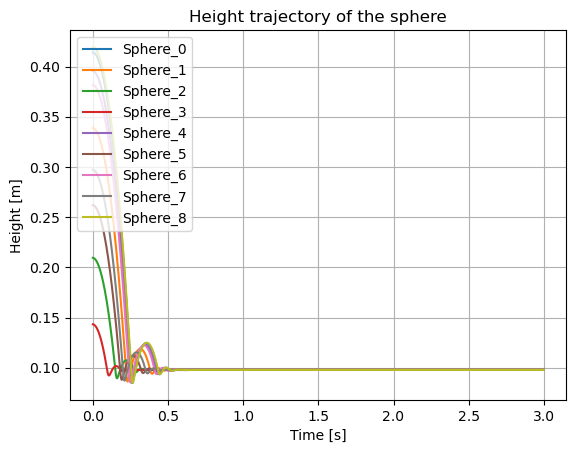

In [22]:
import matplotlib.pyplot as plt


plt.plot(T[:], data_trajectory.base_position[:, :, 2], label=[f"Sphere_{k}" for k in range(batch_size)])
plt.legend(loc='upper left')
plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Height [m]")
plt.title("Height trajectory of the sphere")
plt.show()

In [23]:
import jaxsim.mujoco

mjcf_string, assets = jaxsim.mujoco.ModelToMjcf.convert(
    model.built_from.model,
    cameras=jaxsim.mujoco.loaders.MujocoCamera.build_from_target_view(
        camera_name="sphere_cam",
        lookat=[0, 0, 0.3],
        distance=4,
        azimuth=150,
        elevation=-10,
    ),
)

# Create a helper for each parallel instance.
mj_model_helpers = [
    jaxsim.mujoco.MujocoModelHelper.build_from_xml(
        mjcf_description=mjcf_string, assets=assets
    )
    for _ in range(batch_size)
]

# Create the video recorder.
recorder = jaxsim.mujoco.MujocoVideoRecorder(
    model=mj_model_helpers[0].model,
    data=[helper.data for helper in mj_model_helpers],
    fps=int(1 / model.time_step),
    width=320 * 2,
    height=240 * 2,
)

for data_t in data_trajectory_list:

    for helper, base_position, base_quaternion, joint_position in zip(
        mj_model_helpers,
        data_t.base_position,
        data_t.base_orientation,
        data_t.joint_positions,
        strict=True,
    ):
        helper.set_base_position(position=base_position)
        helper.set_base_orientation(orientation=base_quaternion)

        if model.dofs() > 0:
            helper.set_joint_positions(
                positions=joint_position, joint_names=model.joint_names()
            )

    # Record a new video frame.
    recorder.record_frame(camera_name="sphere_cam")

In [24]:
import mediapy as media

media.show_video(recorder.frames, fps=recorder.fps)

This browser does not support the video tag.
